
## Lección 3: Reducción Dimensional y Preprocesamiento

### A. Preparar un dataset de alta dimensión

En el mundo real, un cliente no se define solo por su edad y su ingreso. Para que nuestra segmentación sea "inteligente", debemos considerar múltiples dimensiones. Sin embargo, tener demasiadas columnas crea el "problema de la alta dimensionalidad", lo que dificulta que los algoritmos de clustering funcionen bien y que nosotros podamos visualizar algo.

Para este ejercicio, simularemos un dataset con las siguientes dimensiones:
1.  **Demográficas:** Edad e Ingresos.
2.  **Conductuales:** Puntuación de gasto y Visitas mensuales.
3.  **Categorías de Gasto:** Montos gastados en Electrónica, Hogar, Ropa, Alimentos y Belleza.
4.  **Digitales:** Tiempo en la app y clics en promociones.

Este conjunto de datos "ancho" será el reto perfecto para nuestras técnicas de reducción dimensional.


---

In [1]:
import pandas as pd
import numpy as np

# Configuración de datos
np.random.seed(42)
n_clientes = 2000

# Generamos un dataset de "Alta Dimensión" (11 variables)
data = {
    'Edad': np.random.randint(18, 70, n_clientes),
    'Ingreso_Anual': np.random.normal(50000, 15000, n_clientes),
    'Puntuacion_Gasto': np.random.uniform(1, 100, n_clientes),
    'Visitas_Mensuales': np.random.poisson(5, n_clientes),
    'Gasto_Electronica': np.random.exponential(200, n_clientes),
    'Gasto_Hogar': np.random.exponential(150, n_clientes),
    'Gasto_Ropa': np.random.exponential(100, n_clientes),
    'Gasto_Alimentos': np.random.normal(300, 50, n_clientes),
    'Gasto_Belleza': np.random.uniform(0, 100, n_clientes),
    'Tiempo_App_Min': np.random.normal(15, 5, n_clientes),
    'Clics_Promo': np.random.poisson(2, n_clientes)
}

df_high_dim = pd.DataFrame(data)

# Inyectamos algunos valores nulos para no perder la costumbre de limpiar
for col in ['Edad', 'Ingreso_Anual', 'Gasto_Electronica']:
    df_high_dim.loc[df_high_dim.sample(frac=0.05).index, col] = np.nan

# Guardamos el dataset maestro
df_high_dim.to_csv('clientes_alta_dimension.csv', index=False)

print("Dataset de alta dimensión (11 variables) creado.")
print(f"Forma del dataset: {df_high_dim.shape}")
display(df_high_dim.head())

Dataset de alta dimensión (11 variables) creado.
Forma del dataset: (2000, 11)


,Edad,Ingreso_Anual,Puntuacion_Gasto,Visitas_Mensuales,Gasto_Electronica,Gasto_Hogar,Gasto_Ropa,Gasto_Alimentos,Gasto_Belleza,Tiempo_App_Min,Clics_Promo
0,56.0,40250.401822,11.479470,7,170.191105,96.224734,157.666691,259.542957,53.922794,11.912606,3
1,69.0,64058.354323,87.428920,3,1150.517047,230.893942,121.695379,331.128566,59.164933,14.126322,3
2,46.0,47575.613818,52.791159,1,391.824830,38.297475,156.864805,386.401560,56.528587,16.072319,2
3,32.0,29880.879935,70.269301,3,1.540074,36.718663,152.295816,380.695955,64.255401,17.732843,1
4,60.0,28608.117010,41.674852,5,10.375685,133.459367,10.981562,280.747007,94.028810,15.516838,1


### B. Implementar PCA y t-SNE con scikit-learn

Para procesar las 11 variables de nuestros clientes de **Retail Insights S.A.**, utilizaremos dos de las técnicas más potentes de reducción dimensional. Es fundamental recordar que ambos algoritmos requieren que los datos estén en la misma escala (normalizados) y no aceptan valores nulos.

#### 1. PCA (Principal Component Analysis)
Es una técnica lineal que busca "resumir" la información creando nuevas variables llamadas Componentes Principales. El primer componente captura la mayor varianza posible de los datos originales. Es ideal para reducir ruido y mantener la estructura global del dataset.

#### 2. t-SNE (t-distributed Stochastic Neighbor Embedding)
A diferencia de PCA, esta es una técnica no lineal. Su objetivo principal es la visualización. Intenta mantener a los puntos que eran "vecinos" en el espacio de alta dimensión cerca también en el plano de 2D. Es excelente para identificar clústeres visuales, aunque es más lento y sensible a sus parámetros (como la perplejidad).

#### Importancia del Preprocesamiento
Usaremos `StandardScaler` para que variables con rangos grandes (como los Ingresos de $50,000) no dominen injustamente sobre variables pequeñas (como los Clics de 0 a 5).

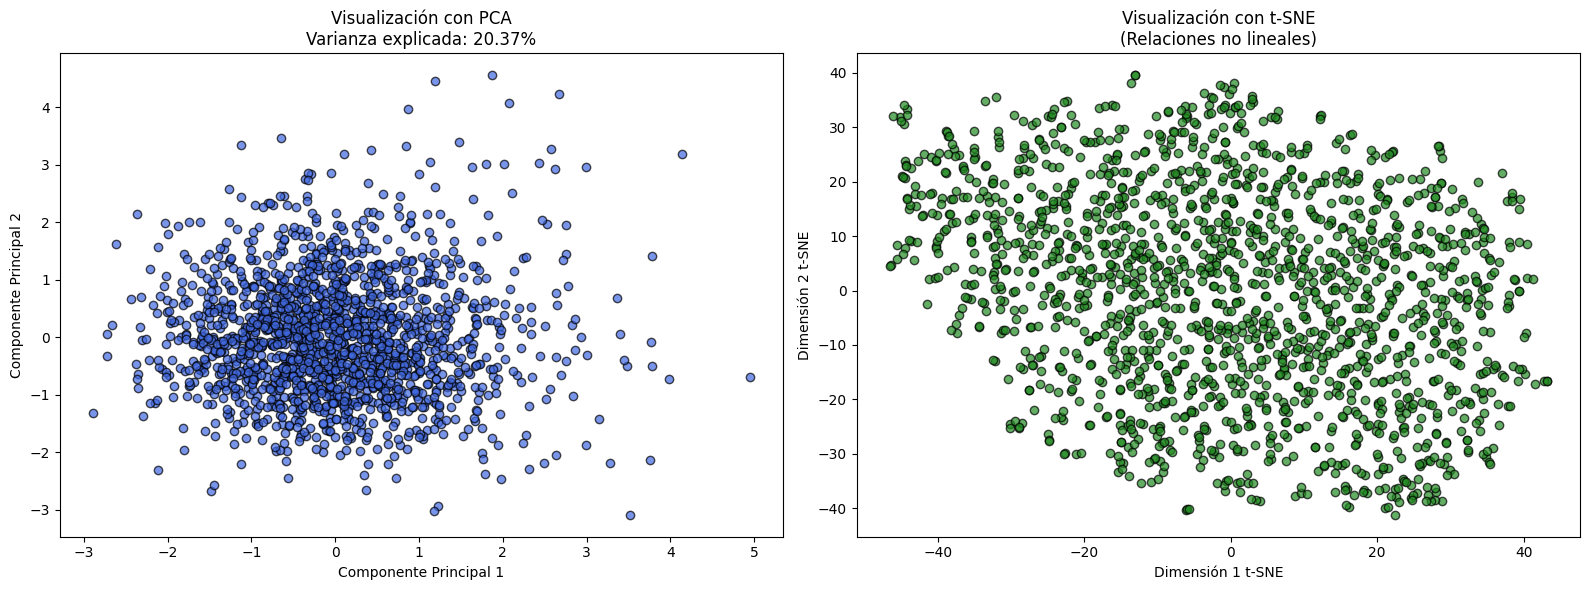

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# 1. Preparación de datos (Cargamos el dataset generado en el paso anterior)
# Nota: Eliminamos nulos ya que PCA y t-SNE no los admiten
df = pd.read_csv('clientes_alta_dimension.csv').dropna()

# Seleccionamos solo las columnas numéricas para el análisis
X = df.values

# 2. Normalización (Paso obligatorio)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Aplicación de PCA (Reducción a 2 dimensiones)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4. Aplicación de t-SNE (Reducción a 2 dimensiones)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# 5. Visualización de resultados
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico PCA
ax1.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7, c='royalblue', edgecolors='k')
ax1.set_title(f'Visualización con PCA\nVarianza explicada: {pca.explained_variance_ratio_.sum():.2%}')
ax1.set_xlabel('Componente Principal 1')
ax1.set_ylabel('Componente Principal 2')

# Gráfico t-SNE
ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.7, c='forestgreen', edgecolors='k')
ax2.set_title('Visualización con t-SNE\n(Relaciones no lineales)')
ax2.set_xlabel('Dimensión 1 t-SNE')
ax2.set_ylabel('Dimensión 2 t-SNE')

plt.tight_layout()
plt.show()

### C. Visualizar y comparar los resultados

Tras aplicar PCA y t-SNE sobre los datos de los clientes de **Retail Insights S.A.**, es momento de evaluar cuál técnica nos ofrece una mejor perspectiva para la futura segmentación. La comparación se basa en dos ejes:

1.  **Preservación de la Estructura Global (PCA):** Nos permite ver la dispersión general de los clientes y cuánta información (varianza) logramos rescatar al reducir las 11 dimensiones originales a solo 2.
2.  **Preservación de la Estructura Local (t-SNE):** Se enfoca en mantener juntos a los clientes que son muy similares entre sí, lo que suele revelar "nubes" o grupos más definidos que el ojo humano puede identificar rápidamente.

Para que la comparación sea justa, utilizaremos la misma escala en ambos gráficos y analizaremos la formación de posibles nichos de mercado.

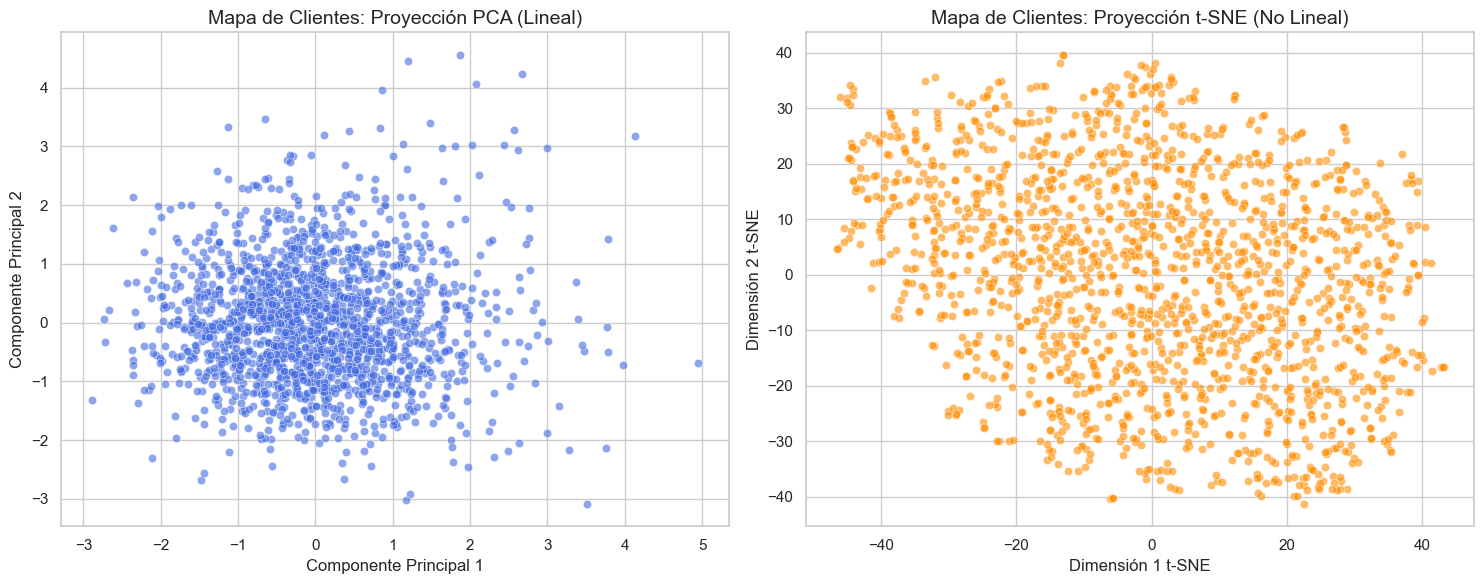

Varianza total capturada por PCA (2 componentes): 20.37%


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuración de estilo y lienzo
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 2. Visualización de PCA
# Eliminamos 'palette' ya que no tenemos una variable 'hue' (etiqueta) todavía
sns.scatterplot(
    x=X_pca[:, 0], 
    y=X_pca[:, 1], 
    ax=axes[0], 
    color="royalblue", 
    alpha=0.6, 
    edgecolor='w'
)
axes[0].set_title('Mapa de Clientes: Proyección PCA (Lineal)', fontsize=14)
axes[0].set_xlabel('Componente Principal 1')
axes[0].set_ylabel('Componente Principal 2')

# 3. Visualización de t-SNE
# Corrección de SyntaxError: se asigna el segundo eje a 'y'
sns.scatterplot(
    x=X_tsne[:, 0], 
    y=X_tsne[:, 1], 
    ax=axes[1], 
    color="darkorange", 
    alpha=0.6, 
    edgecolor='w'
)
axes[1].set_title('Mapa de Clientes: Proyección t-SNE (No Lineal)', fontsize=14)
axes[1].set_xlabel('Dimensión 1 t-SNE')
axes[1].set_ylabel('Dimensión 2 t-SNE')

plt.tight_layout()
plt.show()

# Resumen de varianza para el reporte
print(f"Varianza total capturada por PCA (2 componentes): {pca.explained_variance_ratio_.sum():.2%}")

### D. Justificación de la técnica para Retail Insights S.A.

> ⚠️ **Nota conceptual importante:** PCA y t-SNE **no son técnicas equivalentes ni intercambiables**. Aunque ambas reducen dimensiones, tienen propósitos fundamentalmente distintos dentro del flujo de trabajo:
> - **PCA** es una técnica de reducción dimensional funcional: transforma los datos en nuevas variables (componentes) que conservan la estructura global y las distancias reales. Es apta para alimentar modelos posteriores como K-Means.
> - **t-SNE** es exclusivamente una técnica de **visualización**. Las coordenadas que produce no conservan distancias globales ni son reproducibles de forma determinista, por lo que **no deben usarse como entrada para algoritmos de clustering**.
> 
> La pregunta correcta no es "¿cuál es mejor?", sino **"¿para qué objetivo uso cada una?"**


Tras analizar el comportamiento de ambos algoritmos sobre nuestro dataset de 11 dimensiones, la elección de la técnica depende del objetivo inmediato dentro del flujo de trabajo de la consultora:

#### 1. Para la Visualización y Comunicación (Elección: t-SNE)
Para la presentación final ante el Departamento de Inteligencia de Negocios, **t-SNE** es la técnica adecuada para comunicar resultados.
* **Razón:** Su capacidad para detectar relaciones no lineales permite que los clústeres de clientes se vean como "islas" claramente separadas en 2D. Es mucho más intuitivo para un stakeholder no técnico ver grupos definidos que una nube de puntos dispersa.
* **Limitación a tener en cuenta:** Las posiciones en el gráfico t-SNE no representan distancias reales entre clientes. Úsalo solo para ilustrar, nunca para modelar.

#### 2. Para el Preprocesamiento Técnico y Alimentar los Modelos (Elección: PCA)
Para reducir las 11 variables antes de aplicar K-Means, DBSCAN o agrupamiento jerárquico, **PCA** es la única técnica apropiada.
* **Razón:** PCA mantiene la estructura global y las distancias relativas entre todos los puntos. Además, nos permite eliminar el "ruido" de las 11 variables originales quedándonos solo con los componentes que explican la mayor varianza (ej. el 80% o 90%), lo que hace que el modelo de segmentación sea más robusto y menos pesado computacionalmente.


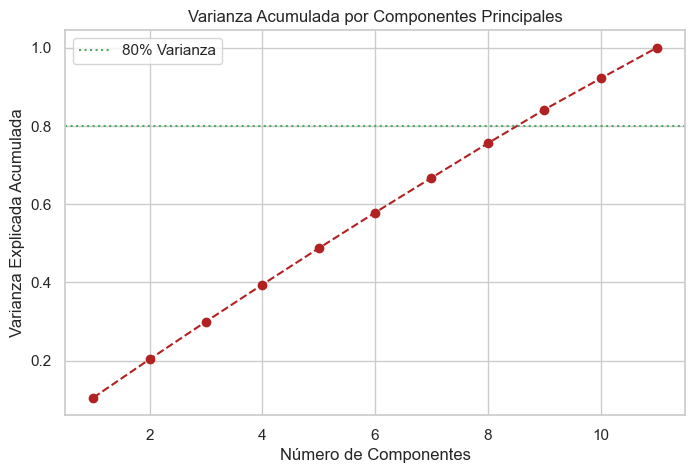

Para capturar el 80% de la información de los clientes, solo necesitamos 9 componentes de los 11 originales.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Calculamos PCA sin reducir componentes inicialmente para ver el panorama completo
pca_full = PCA().fit(X_scaled)
varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

# Visualización de la "Curva de Codo" para dimensiones
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', linestyle='--', color='firebrick')
plt.axhline(y=0.80, color='g', linestyle=':', label='80% Varianza')
plt.title('Varianza Acumulada por Componentes Principales')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.legend()
plt.grid(True)
plt.show()

# Justificación numérica
n_comp_80 = np.argmax(varianza_acumulada >= 0.80) + 1
print(f"Para capturar el 80% de la información de los clientes, solo necesitamos {n_comp_80} componentes de los 11 originales.")

### 3. Breve explicación del resultado

La conclusión es estratégica y clara en sus roles:

- Utilizaremos **PCA** para reducir las 11 variables originales a un número menor de componentes (donde se mantenga al menos el **80% de la varianza**), limpiando el ruido para que los algoritmos de clustering trabajen con mayor precisión. **Este es el dato que entra al modelo.**

- Utilizaremos **t-SNE únicamente para visualización**: genera gráficos 2D que permiten a la gerencia de **Retail Insights** apreciar de forma intuitiva la separación de los grupos detectados. **Este gráfico no alimenta ningún algoritmo.**

En resumen: **PCA transforma los datos → clustering detecta los grupos → t-SNE los dibuja**.
